In [3]:
import os
import copy
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
from enum import Enum

In [4]:
DATASET_ROOT = os.path.abspath(os.path.join("../data"))

In [5]:
class UncertaintyStrategy(Enum):
    U_ZEROS = "u_zeros"
    U_ONES  = "u_ones"
    LSR     = "lsr"

class ProjectionStrategy(Enum):
    PA_ONLY = "PA"
    AP_ONLY = "AP"
    ALL     = "all"

class ViewStrategy(Enum):
    FRONTAL_ONLY = "Frontal"
    LATERAL_ONLY = "Lateral"
    ALL          = "all"

CHEXPERT_LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture'
]

CANONICAL_LABELS = [
    'No_Finding', 'Enlarged_Cardiomediastinum', 'Cardiomegaly',
    'Lung_Opacity', 'Lung_Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Effusion',
    'Pleural_Other', 'Fracture',
]

CHEXPERT_TO_CANONICAL = {
    'No Finding':                 'No_Finding',
    'Enlarged Cardiomediastinum': 'Enlarged_Cardiomediastinum',
    'Cardiomegaly':               'Cardiomegaly',
    'Lung Opacity':               'Lung_Opacity',
    'Lung Lesion':                'Lung_Lesion',
    'Edema':                      'Edema',
    'Consolidation':              'Consolidation',
    'Pneumonia':                  'Pneumonia',
    'Atelectasis':                'Atelectasis',
    'Pneumothorax':               'Pneumothorax',
    'Pleural Effusion':           'Effusion',
    'Pleural Other':              'Pleural_Other',
    'Fracture':                   'Fracture',
}


class CheXpertDataset(Dataset):
    def __init__(self, root, csv_path, transform=None,
                 projection=ProjectionStrategy.AP_ONLY,
                 view=ViewStrategy.FRONTAL_ONLY,
                 uncertainty=None, lsr_alpha=0.55, lsr_beta=0.85):
        self.root      = root
        self.transform = transform
        self.lsr_alpha = lsr_alpha
        self.lsr_beta  = lsr_beta
        if uncertainty is None:
            self.uncertainty = {l: UncertaintyStrategy.LSR for l in CHEXPERT_LABELS}
        else:
            self.uncertainty = uncertainty
        df = pd.read_csv(csv_path)
        self.df = self._filter_view(df, view)
        self.df = self._filter_projection(self.df, projection)

    def _filter_view(self, df, s):
        return df if s == ViewStrategy.ALL else df[df['Frontal/Lateral'] == s.value].reset_index(drop=True)

    def _filter_projection(self, df, s):
        return df if s == ProjectionStrategy.ALL else df[df['AP/PA'] == s.value].reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = self._load_image(row)
        except Exception:
            return self.__getitem__(idx + 1)
        return image, self._extract_labels(row)

    def _load_image(self, row):
        img = Image.open(os.path.join(self.root, row['Path'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

    def _extract_labels(self, row):
        labels = {}
        for label in CHEXPERT_LABELS:
            value = row[label]
            if pd.isna(value):
                labels[label] = 0
            elif int(value) == -1:
                s = self.uncertainty[label]
                if s == UncertaintyStrategy.U_ZEROS:
                    labels[label] = 0
                elif s == UncertaintyStrategy.U_ONES:
                    labels[label] = 1
                else:
                    labels[label] = np.random.uniform(self.lsr_alpha, self.lsr_beta)
            else:
                labels[label] = int(value)
        return labels


class UnifiedDataset(Dataset):
    _MAPPINGS = {'chexpert': CHEXPERT_TO_CANONICAL}

    def __init__(self, datasets, transform=None):
        self.datasets  = datasets
        self._index_map = [
            (name, i)
            for name, ds in datasets.items()
            for i in range(len(ds))
        ]
        self.transform = transform

    def __len__(self): return len(self._index_map)

    def __getitem__(self, idx):
        name, local_idx  = self._index_map[idx]
        image, raw_labels = self.datasets[name][local_idx]
        labels = self._map_labels(raw_labels, self._MAPPINGS[name])
        labels_tensor = torch.tensor(
            [labels[l] for l in CANONICAL_LABELS], dtype=torch.float32
        )
        if self.transform:
            image = self.transform(image)
        return image, labels_tensor

    def _map_labels(self, raw_labels, mapping):
        canonical = {label: 0 for label in CANONICAL_LABELS}
        for pat, value in raw_labels.items():
            target = mapping.get(pat)
            if target is not None:
                canonical[target] = value
        return canonical

    def class_distribution(self):
        counts = {label: 0 for label in CANONICAL_LABELS}
        for name, ds in self.datasets.items():
            mapping = self._MAPPINGS[name]
            for _, row in ds.df.iterrows():
                labels = ds._extract_labels(row)
                mapped = self._map_labels(labels, mapping)
                for label, value in mapped.items():
                    if value == 1:
                        counts[label] += 1
        return counts

# Dataset y Splits

In [6]:
uncertainty_config = {
    'No Finding':                 UncertaintyStrategy.U_ZEROS,
    'Enlarged Cardiomediastinum': UncertaintyStrategy.U_ONES,
    'Cardiomegaly':               UncertaintyStrategy.U_ONES,
    'Lung Opacity':               UncertaintyStrategy.U_ONES,
    'Lung Lesion':                UncertaintyStrategy.U_ZEROS,
    'Edema':                      UncertaintyStrategy.U_ONES,
    'Consolidation':              UncertaintyStrategy.U_ONES,
    'Pneumonia':                  UncertaintyStrategy.U_ONES,
    'Atelectasis':                UncertaintyStrategy.U_ONES,
    'Pneumothorax':               UncertaintyStrategy.U_ZEROS,
    'Pleural Effusion':           UncertaintyStrategy.U_ONES,
    'Pleural Other':              UncertaintyStrategy.U_ZEROS,
    'Fracture':                   UncertaintyStrategy.U_ZEROS,
}


def make_chexpert_splits(cx_train, cx_val, seed=42, ratios=(0.8, 0.1, 0.1)):
    df = pd.concat([cx_train.df, cx_val.df], ignore_index=True)
    df['patient_id'] = df['Path'].apply(lambda x: x.split('/')[-1].split('_')[0])
    patients = np.array(df['patient_id'].unique())
    np.random.default_rng(seed).shuffle(patients)
    n       = len(patients)
    n_train = int(n * ratios[0])
    n_val   = int(n * ratios[1])
    train_p = set(patients[:n_train])
    val_p   = set(patients[n_train:n_train + n_val])
    test_p  = set(patients[n_train + n_val:])
    train_paths = set(df[df['patient_id'].isin(train_p)]['Path'])
    val_paths   = set(df[df['patient_id'].isin(val_p)]['Path'])
    test_paths  = set(df[df['patient_id'].isin(test_p)]['Path'])
    print(f'train: {len(train_paths)} | val: {len(val_paths)} | test: {len(test_paths)}')
    return train_paths, val_paths, test_paths


cx_train_raw = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'train.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY,
)
cx_val_raw = CheXpertDataset(
    root=DATASET_ROOT,
    csv_path=os.path.join(DATASET_ROOT, 'chexpert', 'valid.csv'),
    uncertainty=uncertainty_config,
    projection=ProjectionStrategy.ALL,
    view=ViewStrategy.FRONTAL_ONLY,
)

train_paths, val_paths, test_paths = make_chexpert_splits(cx_train_raw, cx_val_raw)

df_all = pd.concat([cx_train_raw.df, cx_val_raw.df], ignore_index=True)

chexpert_train = copy.deepcopy(cx_train_raw)
chexpert_val   = copy.deepcopy(cx_train_raw)
chexpert_test  = copy.deepcopy(cx_train_raw)

chexpert_train.df = df_all[df_all['Path'].isin(train_paths)].reset_index(drop=True)
chexpert_val.df   = df_all[df_all['Path'].isin(val_paths)].reset_index(drop=True)
chexpert_test.df  = df_all[df_all['Path'].isin(test_paths)].reset_index(drop=True)

train_unified = UnifiedDataset({'chexpert': chexpert_train})
val_unified   = UnifiedDataset({'chexpert': chexpert_val})
test_unified  = UnifiedDataset({'chexpert': chexpert_test})

train: 153487 | val: 18871 | test: 18871


## Preprocesamiento + Data Augmentation

In [7]:
normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

transform_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    normalize,
])

train_augs = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    normalize,
])

chexpert_train.transform = train_augs
chexpert_val.transform   = transform_test
chexpert_test.transform  = transform_test

# Particionado: Distribución por clase en cada partición

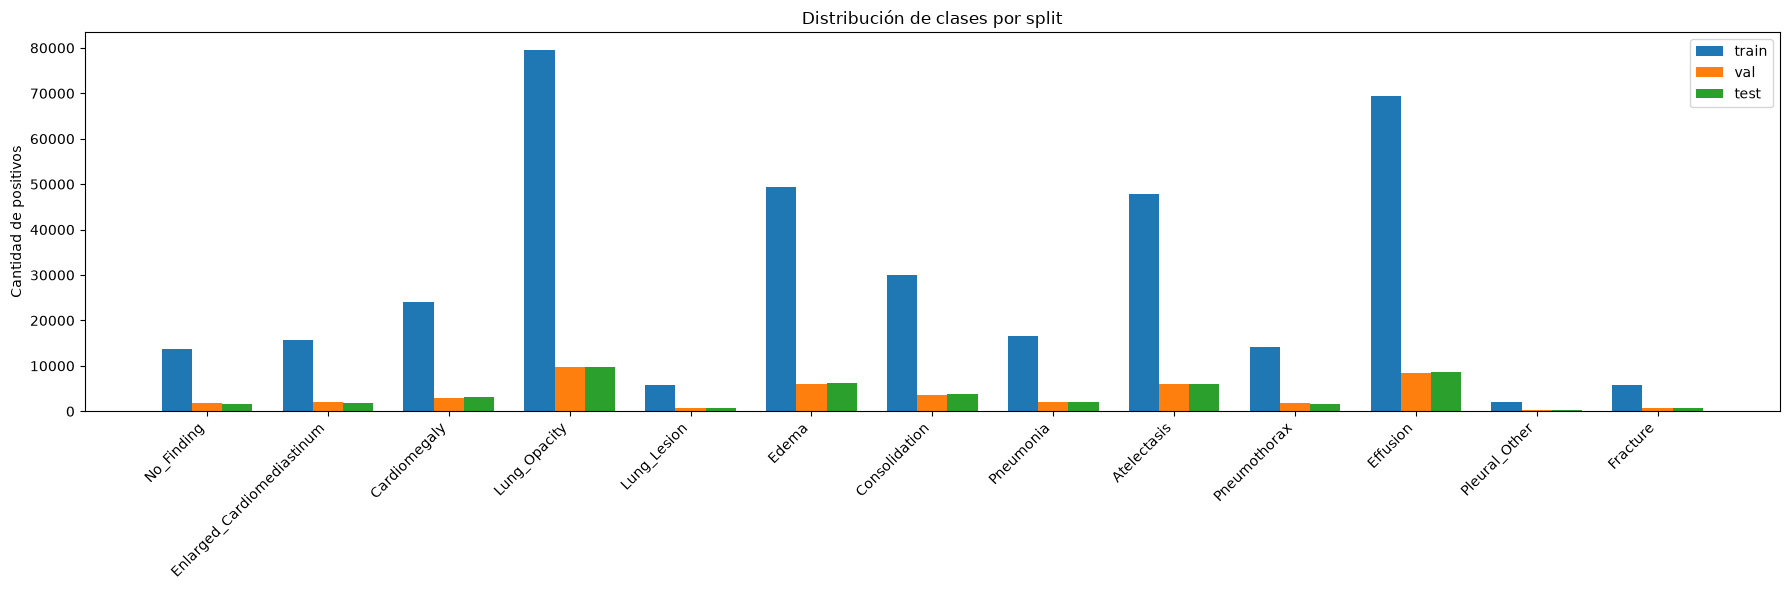

In [8]:
splits = {
    "train": train_unified.class_distribution(),
    "val":   val_unified.class_distribution(),
    "test":  test_unified.class_distribution(),
}

x = np.arange(len(CANONICAL_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 6))

for i, (split_name, counts) in enumerate(splits.items()):
    values = [counts[label] for label in CANONICAL_LABELS]
    ax.bar(x + i * width, values, width, label=split_name)

ax.set_xticks(x + width)
ax.set_xticklabels(CANONICAL_LABELS, rotation=45, ha="right")
ax.set_ylabel("Cantidad de positivos")
ax.set_title("Distribución de clases por split")
ax.legend()

plt.tight_layout()
plt.show()

## DataLoaders

In [11]:
BATCH_SIZE  = 128
NUM_WORKERS = 4
torch.manual_seed(42)

train_loader = DataLoader(train_unified, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_unified,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_unified,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

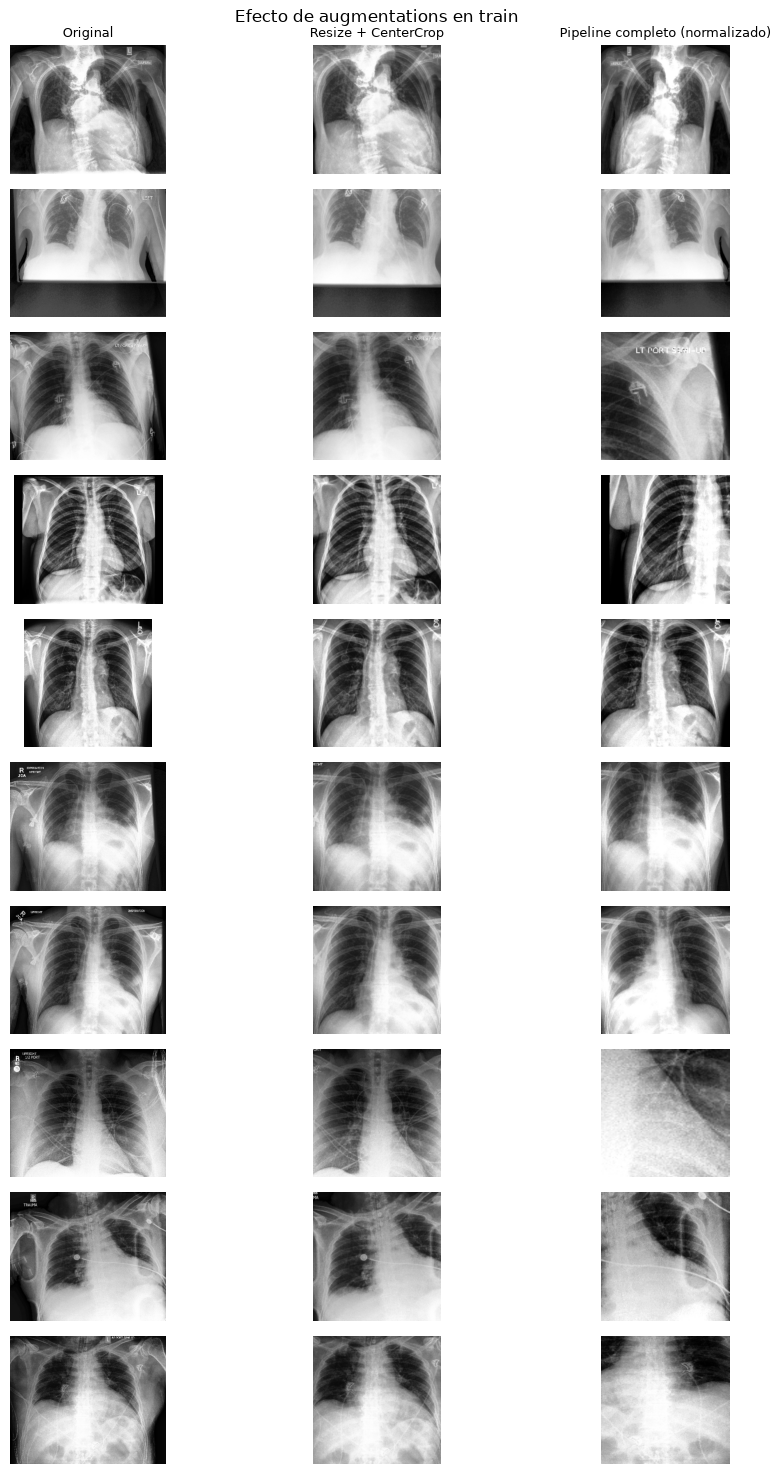

In [10]:
def to_displayable(result):
    if isinstance(result, torch.Tensor):
        img = result.permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        return img.mean(axis=2)
    return result

fig, axes = plt.subplots(10, 3, figsize=(10, 15))

col_titles = ["Original", "Resize + CenterCrop", "Pipeline completo (normalizado)"]
partial_transforms = [
    None,
    T.Compose([T.Resize(256), T.CenterCrop(224)]),
    train_augs,
]

for row_idx in range(10):
    row = chexpert_train.df.iloc[row_idx]
    for col_idx, tf in enumerate(partial_transforms):
        chexpert_train.transform = tf
        ax = axes[row_idx, col_idx]
        ax.imshow(to_displayable(chexpert_train._load_image(row)), cmap="gray")
        ax.axis("off")
        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=9)

chexpert_train.transform = train_augs
plt.suptitle("Efecto de augmentations en train")
plt.tight_layout()
plt.show()

# Visualizar Batch

In [ ]:
def visualize_batch(loader, n_images=8):
    images, labels = next(iter(loader))

    # Dimensiones y rango
    print(f"Tensor shape : {images.shape}  → (batch, canales, alto, ancho)")
    print(f"Rango normalizado : [{images.min():.3f}, {images.max():.3f}]")
    print(f"Labels shape : {labels.shape}")

    # Desnormalizar para visualización
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    imgs_denorm = (images[:n_images] * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(2, n_images // 2, figsize=(16, 6))
    axes = axes.flatten()

    for i in range(n_images):
        img_vis = imgs_denorm[i].permute(1, 2, 0).numpy().mean(axis=2)
        axes[i].imshow(img_vis, cmap="gray")
        axes[i].axis("off")

        # Etiquetas positivas de esta imagen
        pos = [CANONICAL_LABELS[j] for j, v in enumerate(labels[i]) if v == 1]
        axes[i].set_title("\n".join(pos) if pos else "No Finding", fontsize=7)

    plt.suptitle("Batch de train — imágenes desnormalizadas")
    plt.tight_layout()
    plt.show()

visualize_batch(train_loader)